In [7]:
import awkward as ak
import pathlib
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from mpl_toolkits.mplot3d import Axes3D
#import atlas_mpl_style as ampl
import numpy as np
from particle import Particle


In [8]:
events_rho = ak.from_json(pathlib.Path("test_inputJZ4.json"))

In [9]:
events_rho[1]

<Record {runNumber: 410000, ...} type='{runNumber: int64, eventNumber: int6...'>

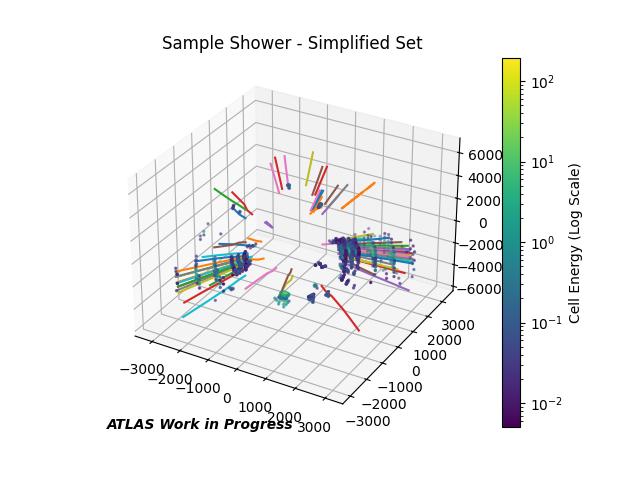

In [10]:
%matplotlib widget
ax = plt.figure().add_subplot(projection='3d')
ax.set_title("Sample Shower - Simplified Set")
ax.text(0,0,0,f"ATLAS Work in Progress", style="italic", weight="bold", transform=ax.transAxes)

event = events_rho[1]

for track in event["tracks"]:
    name = Particle.from_pdgid(track['truthPartPdgId']).name
    ax.plot(track['hits']['x'].to_list(), 
             track['hits']['y'].to_list(), 
             track['hits']['z'].to_list(),
             label=name)
    
scatter = ax.scatter(event['cells']['x'].to_list(), 
            event['cells']['y'].to_list(), 
            event['cells']['z'].to_list(),
           c=event['cells']['cell_E'].to_list(),
           norm=LogNorm(),
           cmap='viridis',
            label="Cells", s=2) #

plt.colorbar(scatter, ax=ax, label='Cell Energy (Log Scale)')
# ax.legend()
plt.savefig('testJZ4.png', dpi=400, transparent=True)

In [11]:
x = np.array([1,2,3])

In [12]:
x+2

array([3, 4, 5])